# K-Means Clustering

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
rdf = df[["Age","Annual Income (k$)"]]
rdf

,Age,Annual Income (k$)
0,19,15
1,21,15
2,20,16
3,23,16
4,31,17
...,...,...
195,35,120
196,45,126
197,32,126
198,32,137


## MinMax_Scaler

In [4]:
scaler = MinMaxScaler()

rdf = scaler.fit_transform(rdf)
rdf

array([[0.01923077, 0.        ],
       [0.05769231, 0.        ],
       [0.03846154, 0.00819672],
       [0.09615385, 0.00819672],
       [0.25      , 0.01639344],
       [0.07692308, 0.01639344],
       [0.32692308, 0.02459016],
       [0.09615385, 0.02459016],
       [0.88461538, 0.03278689],
       [0.23076923, 0.03278689],
       [0.94230769, 0.03278689],
       [0.32692308, 0.03278689],
       [0.76923077, 0.04098361],
       [0.11538462, 0.04098361],
       [0.36538462, 0.04098361],
       [0.07692308, 0.04098361],
       [0.32692308, 0.04918033],
       [0.03846154, 0.04918033],
       [0.65384615, 0.06557377],
       [0.32692308, 0.06557377],
       [0.32692308, 0.07377049],
       [0.13461538, 0.07377049],
       [0.53846154, 0.08196721],
       [0.25      , 0.08196721],
       [0.69230769, 0.10655738],
       [0.21153846, 0.10655738],
       [0.51923077, 0.10655738],
       [0.32692308, 0.10655738],
       [0.42307692, 0.1147541 ],
       [0.09615385, 0.1147541 ],
       [0.

In [5]:
sdf = pd.DataFrame(rdf)
sdf.to_csv("Scater.csv", index=False)

In [6]:
sdf

,0,1
0,0.019231,0.000000
1,0.057692,0.000000
2,0.038462,0.008197
3,0.096154,0.008197
4,0.250000,0.016393
...,...,...
195,0.326923,0.860656
196,0.519231,0.909836
197,0.269231,0.909836
198,0.269231,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

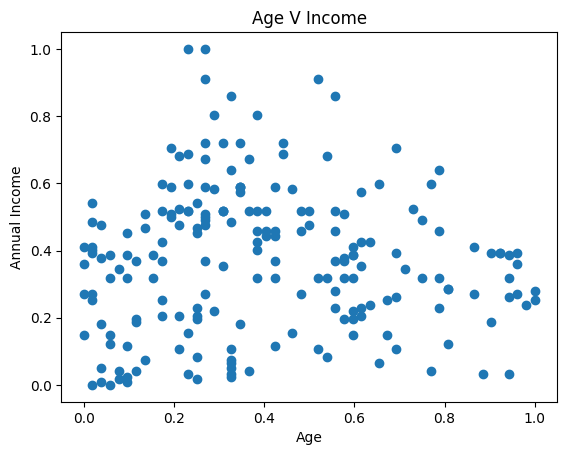

In [7]:
x = sdf[0]
y = sdf[1]

plt.scatter(x,y)
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title("Age V Income")
plt.show

## Elbow_Technique

In [8]:
k_values = range(1, 10)

sse = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sdf)
    sse.append(kmeans.inertia_)

sse

[23.583906150363603,
 13.028938428018286,
 7.493807691007751,
 6.08784183514571,
 4.793697493647492,
 3.9872861135843802,
 3.449307145123126,
 2.6584817643624086,
 2.469654818442098]

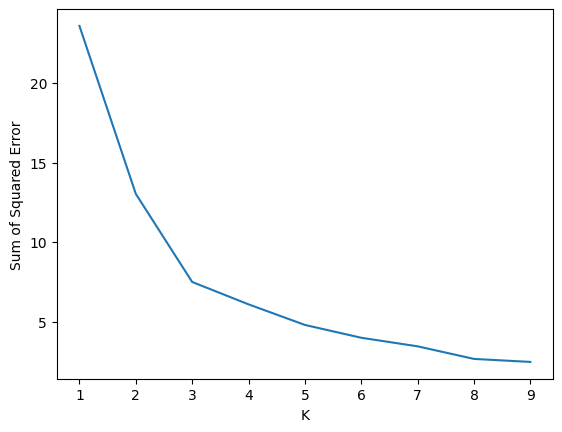

In [9]:
plt.xlabel("K")
plt.ylabel("Sum of Squared Error")
plt.plot(k_values,sse)

## Final Processing

In [10]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [11]:
y_pred = km.fit_predict(sdf)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 1, 0, 2, 2, 1, 2, 2, 0, 2, 2, 0,
       1, 2, 2, 0, 2, 1, 1, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2,
       2, 0, 1, 0, 0, 0, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [12]:
sdf["Cluster"] = y_pred
sdf

,0,1,Cluster
0,0.019231,0.000000,0
1,0.057692,0.000000,0
2,0.038462,0.008197,0
3,0.096154,0.008197,0
4,0.250000,0.016393,0
...,...,...,...
195,0.326923,0.860656,1
196,0.519231,0.909836,1
197,0.269231,0.909836,1
198,0.269231,1.000000,1


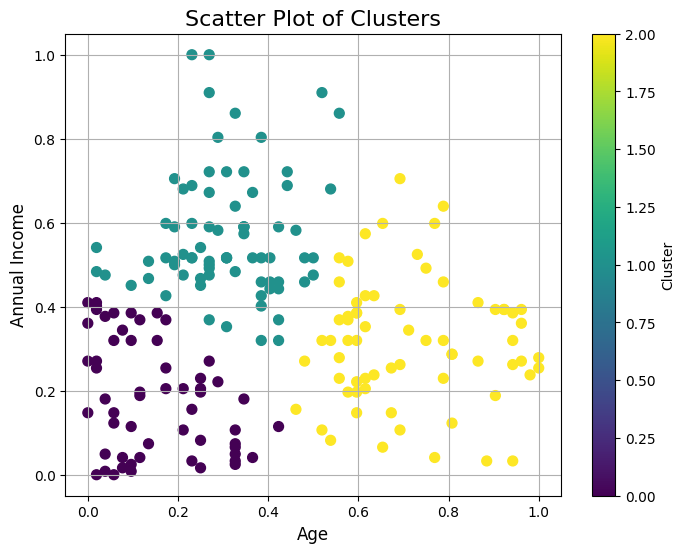

In [15]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(sdf[0], sdf[1], c=sdf['Cluster'], cmap='viridis', s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('Scatter Plot of Clusters',fontsize = 16)
plt.xlabel('Age',fontsize = 12)
plt.ylabel('Annual Income',fontsize = 12)
plt.grid()
plt.show()